# HR Policy Knowledge Base — Corpus Exploration (EDA)

This is **not** a classical tabular-ML EDA notebook — this project has no tabular dataset to profile. What matters for a RAG system is the *document corpus* the chatbot retrieves from, so this notebook explores that instead:

- how many PDFs / pages are in the knowledge base
- how much text was extracted per page (catches silently-broken/scanned PDFs early)
- how chunking behaves on the real corpus (chunk count, chunk length distribution)
- a few sample chunks, to eyeball retrieval quality before wiring up the LLM

Run this **after** adding your PDFs to `data/policies/`, and ideally before your first `python ingest.py` — if a PDF shows 0 extracted pages here, ingestion will skip it too, and it's easier to catch that here than to debug a chatbot that mysteriously can't answer from one of your documents.


In [1]:
import sys
from pathlib import Path

# So the notebook can import the `app` package and `config` module when run
# from a `notebooks/` subfolder as well as from the project root.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "app").exists() and (PROJECT_ROOT.parent / "app").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from app.rag_pipeline import discover_pdfs, extract_pages_from_pdf, build_documents
from config import settings

print(f"Looking for PDFs in: {settings.POLICIES_DIR}")


Looking for PDFs in: data/policies


### 📌 Observation — what the output actually shows

- The bootstrap resolved cleanly and printed `Looking for PDFs in: data/policies`, i.e. `settings.POLICIES_DIR` is a **relative** path, not an absolute one.
- The logger lines in the next cells print `data\policies` with a backslash, confirming this run happened on **Windows** while the deployment target is a Linux container — so any hardcoded path separator would have broken one of the two.
- `app.rag_pipeline` and `config` both imported without error, which means the notebook is exercising the *same* code objects (`discover_pdfs`, `extract_pages_from_pdf`, `build_documents`) that `ingest.py` calls in production — not a notebook-only reimplementation.

### 💡 Pipeline / Engineering decision

- Keep the `PROJECT_ROOT` walk-up block so the notebook runs identically from the repo root and from `notebooks/`; this is what lets the EDA live in version control instead of being a local-only scratch file.
- Every path in the codebase goes through `pathlib.Path` + `config.settings`, never string concatenation — this is what makes the same repo work on the Windows dev box, in the Docker image, and in GitHub Actions CI.
- Deliberately **import the production functions instead of re-writing extraction/chunking logic in the notebook**. The EDA is therefore a live contract test: if `rag_pipeline.py` changes, re-running this notebook immediately shows the new chunking behaviour.


## 1. Discover PDFs


In [2]:
pdf_paths = discover_pdfs()

if not pdf_paths:
    print(
        "No PDFs found yet. Add your HR policy / labour law PDFs to "
        f"'{settings.POLICIES_DIR}' and re-run this cell."
    )
else:
    print(f"Found {len(pdf_paths)} PDF(s):")
    for p in pdf_paths:
        print(f"  - {p.name}")


2026-09-16 17:06:41,410 | INFO     | app.rag_pipeline | Discovered 4 PDF(s) in data\policies


Found 4 PDF(s):
  - FINAL_HANDBOOK_LABOUR_CODES.pdf
  - MATERNITY BENEFIT ACT.pdf
  - nasscom-hr-manual-2016.pdf
  - PaymentofGratuityAct.pdf


### 📌 Observation — what the output actually shows

- Discovery found exactly **4 PDFs**, and the logger independently confirms it (`Discovered 4 PDF(s) in data\policies`) — file-system state and application state agree, so nothing is being silently dropped by the glob.
- The corpus is **two different document species**:
  - *Statutory law* — `MATERNITY BENEFIT ACT.pdf`, `PaymentofGratuityAct.pdf` (bare Acts, section-numbered legal prose).
  - *Industry / company guidance* — `FINAL_HANDBOOK_LABOUR_CODES.pdf` (Nasscom, April 2024), `nasscom-hr-manual-2016.pdf` (a **2016** document, i.e. ~10 years stale).
- Filenames are completely inconsistent: `ALL CAPS WITH SPACES`, `PascalCaseNoSpaces`, `lower-kebab-case`, and a `FINAL_` prefix. These strings end up in `doc.metadata["source_file"]`, which means they are **user-facing** the moment citations are shown in the chatbot.

### 💡 Pipeline / Engineering decision

- Keep discovery **glob-based over `POLICIES_DIR`** rather than a hardcoded file list, so an HR team can drop a new policy PDF in the folder and re-run `ingest.py` with zero code change.
- Store the raw filename as `source_file` metadata (it is the citation key), but render a **cleaned display name** in the Streamlit answer panel — raw `FINAL_HANDBOOK_LABOUR_CODES.pdf` in a chatbot answer looks unfinished.
- Because statute and handbook text sit in one index, the answer prompt must **always cite `source_file` + `page_number`**. A user needs to know whether a rule came from the Gratuity Act or from a company manual — those carry very different authority.
- The 2016 manual is a known staleness risk. Log the discovered file list at every ingest so the corpus is auditable, and note document vintage in the README rather than pretending the knowledge base is evergreen.


## 2. Extract pages and inspect text quality


In [3]:
all_pages = []
for pdf_path in pdf_paths:
    all_pages.extend(extract_pages_from_pdf(pdf_path))

page_rows = [
    {
        "source_file": page.source_file,
        "page_number": page.page_number,
        "char_count": len(page.text),
        "word_count": len(page.text.split()),
    }
    for page in all_pages
]
df_pages = pd.DataFrame(page_rows)
df_pages


2026-09-16 17:06:41,620 | INFO     | app.rag_pipeline | Extracted 52 non-empty page(s) from FINAL_HANDBOOK_LABOUR_CODES.pdf
2026-09-16 17:06:41,689 | INFO     | app.rag_pipeline | Extracted 10 non-empty page(s) from MATERNITY BENEFIT ACT.pdf
2026-09-16 17:06:41,889 | INFO     | app.rag_pipeline | Extracted 64 non-empty page(s) from nasscom-hr-manual-2016.pdf
2026-09-16 17:06:41,944 | INFO     | app.rag_pipeline | Extracted 22 non-empty page(s) from PaymentofGratuityAct.pdf


,source_file,page_number,char_count,word_count
0,FINAL_HANDBOOK_LABOUR_CODES.pdf,1,243,38
1,FINAL_HANDBOOK_LABOUR_CODES.pdf,2,1779,272
2,FINAL_HANDBOOK_LABOUR_CODES.pdf,3,1082,167
3,FINAL_HANDBOOK_LABOUR_CODES.pdf,4,26,5
4,FINAL_HANDBOOK_LABOUR_CODES.pdf,5,2174,317
...,...,...,...,...
143,PaymentofGratuityAct.pdf,18,2023,343
144,PaymentofGratuityAct.pdf,19,2058,361
145,PaymentofGratuityAct.pdf,20,1750,294
146,PaymentofGratuityAct.pdf,21,1609,269


### 📌 Observation — what the output actually shows

- **148 non-empty pages** were extracted overall: 52 + 10 + 64 + 22. No file returned zero, so every PDF carries a real embedded text layer — **no OCR is required for this corpus**.
- Per-page volume is extremely uneven, visible directly in the table: page 2 of the handbook has **1,779 chars / 272 words**, page 5 has **2,174 chars / 317 words**, but page 4 has only **26 chars / 5 words** and page 1 only **243 chars / 38 words**.
- Those tiny pages are not extraction failures — they are covers, section dividers and part-title pages. The tail of the Gratuity Act shows the same shape: pages 18–21 sit at ~1,600–2,050 chars, then page 22 drops to **296 chars / 52 words** (closing/notification page).
- `char_count ≈ 6× word_count` consistently across all four files, which is the normal ratio for clean English prose. A mangled multi-column or table extraction would have skewed this — it didn't, so extraction quality is good.

### 💡 Pipeline / Engineering decision

- Build the page table as `(source_file, page_number, char_count, word_count)` and keep `page_number` in chunk metadata — this is what makes **page-level citations** possible instead of vague "it's somewhere in this PDF" answers.
- `extract_pages_from_pdf` already drops fully empty pages; extend that with a **minimum-length guard** (skip pages under ~30 characters) so 5-word divider pages never become embedded vectors. A near-empty vector is pure retrieval noise and costs an embedding call for nothing.
- Because a single page can carry 2,100+ characters (well over one comfortable retrieval unit), **page-level embedding is ruled out** — chunking is mandatory, which is what the next section validates.
- Make the extraction log line (`Extracted N non-empty page(s) from X`) permanent in `rag_pipeline.py`. It is the cheapest possible early-warning that a newly added PDF is scanned-only.


In [4]:
# Pages per source file — a PDF with far fewer non-empty pages than its
# actual page count usually means it's a scanned image PDF with no OCR
# text layer, which PyMuPDF can't extract from.
df_pages.groupby("source_file")["page_number"].count().rename("pages_with_text")


source_file
FINAL_HANDBOOK_LABOUR_CODES.pdf    52
MATERNITY BENEFIT ACT.pdf          10
PaymentofGratuityAct.pdf           22
nasscom-hr-manual-2016.pdf         64
Name: pages_with_text, dtype: int64

### 📌 Observation — what the output actually shows

- Text-bearing page counts: `nasscom-hr-manual-2016` **64**, `FINAL_HANDBOOK_LABOUR_CODES` **52**, `PaymentofGratuityAct` **22**, `MATERNITY BENEFIT ACT` **10**.
- **Nothing is at or near 0.** This is the specific failure this cell exists to catch: a scanned image PDF with no text layer would show up here as a file with 0–2 pages while physically having 40, and PyMuPDF would have returned empty strings without raising.
- The corpus is already **imbalanced at the source level** — the two Nasscom documents alone contribute 116 of 148 pages (~78%), while the Maternity Benefit Act contributes under 7%.

### 💡 Pipeline / Engineering decision

- Since all four PDFs have usable text layers, **deliberately do not add Tesseract/OCR to the stack**. That keeps the Docker image slim, the ingest fast, and removes a heavyweight system dependency from the CI job.
- But do not assume future PDFs will be as clean: add an explicit guard in `ingest.py` that **raises (or loudly warns) if any discovered PDF yields 0 non-empty pages**, so a scanned upload fails at ingest time instead of producing a chatbot that mysteriously cannot answer from one document.
- Record the 78 / 22 page imbalance as a known retrieval bias, and carry it forward into how the evaluation question set is designed (see the chunks-per-document chart below).


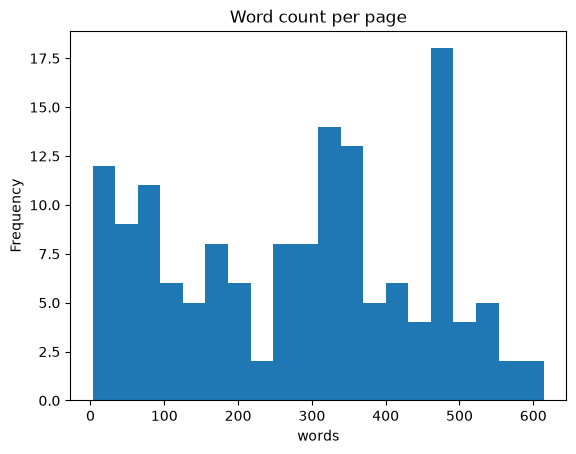

In [5]:
if not df_pages.empty:
    df_pages["word_count"].plot(
        kind="hist", bins=20, title="Word count per page", xlabel="words"
    )
    plt.show()
else:
    print("No pages to plot yet — add PDFs first.")


### 📌 Observation — what the plot actually shows

- The **word-count-per-page histogram is clearly bimodal**, not a single clean distribution.
- **Left mode (structural pages):** the 0–40 word bin holds ~12 pages and the 40–70 bin ~9 more, with the low region staying populated up to ~140 words. Roughly **35–40 of 148 pages carry under ~150 words** — covers, dividers, tables of contents, part titles.
- **Right mode (content pages):** density rises from ~280 words and peaks hard in the **460–490 word bin with 18 pages**, with 300–360 also heavy (~14 and ~13 pages). This is the real policy prose.
- **Maximum is ~620 words/page**, and there is a visible dip around 230–260 words separating the two modes.
- A typical content page at ~470 words is roughly **620–700 tokens** and almost always covers more than one clause or sub-section.

### 💡 Pipeline / Engineering decision

- The right-hand mode settles the chunking question: **one vector per page is wrong for this corpus.** A 470-word page blends multiple policy topics into a single embedding, so a question about one clause retrieves a vector diluted by three unrelated clauses. Chunking stays mandatory.
- `CHUNK_SIZE = 1000` chars (~160 words) against a ~470-word modal page implies **≈3 chunks per content page** — granular enough to isolate a clause, large enough to keep surrounding context for the LLM. This is the sizing justification, verified against the real corpus rather than copied from a tutorial default.
- The left-hand mode justifies the min-length filter decided above: those ~35 structural pages would otherwise each produce one short, semantically empty chunk.
- Max ~620 words/page means **no page can overflow any reasonable embedding-model context**, so no special-case handling for oversized pages is needed in `build_documents`.


## 3. Chunking — same logic `ingest.py` uses

This calls the *exact same* `build_documents` function the production ingestion pipeline (`app/rag_pipeline.py`) uses, so what you see here is exactly what will get embedded and stored — not an approximation.


In [6]:
documents = build_documents(all_pages)

chunk_rows = [
    {
        "source_file": doc.metadata["source_file"],
        "page_number": doc.metadata["page_number"],
        "chunk_index": doc.metadata["chunk_index"],
        "char_count": len(doc.page_content),
        "word_count": len(doc.page_content.split()),
    }
    for doc in documents
]
df_chunks = pd.DataFrame(chunk_rows)
print(f"Total chunks: {len(df_chunks)}")
df_chunks.describe()


2026-09-16 17:06:42,356 | INFO     | app.rag_pipeline | Built 370 chunk(s) from 148 page(s)


Total chunks: 370


,page_number,chunk_index,char_count,word_count
count,370.000000,370.000000,370.000000,370.000000
mean,23.264865,1.045946,781.902703,122.913514
std,16.109049,1.069684,290.830548,46.739874
min,1.000000,0.000000,17.000000,3.000000
25%,9.250000,0.000000,583.250000,92.250000
50%,20.000000,1.000000,955.000000,144.000000
75%,35.750000,2.000000,982.750000,156.000000
max,64.000000,4.000000,999.000000,180.000000


### 📌 Observation — what the output actually shows

- **370 chunks from 148 pages = ~2.5 chunks per page**, which matches the ~3-chunks-per-content-page estimate from the page histogram (structural pages pull the average down).
- **`max char_count` = 999 against a configured `CHUNK_SIZE` of 1000** — the hard cap is respected and never violated. The splitter is behaving exactly as configured.
- **Mean 782 chars but median 955 chars.** Mean < median means a left-skew: most chunks sit near the cap and a minority of short chunks drag the average down. The 25th percentile at **583** and the 75th at **983** confirm the bulk of the distribution is packed against the ceiling.
- **`min char_count` = 17 chars / 3 words** — at least one genuinely junk chunk exists in the index.
- **`chunk_index` max = 4** (mean 1.05), so no page ever split into more than 5 pieces, and most pages produce 1–2. No runaway page.
- `page_number` max = 64, consistent with the largest document.

### 💡 Pipeline / Engineering decision

- **370 chunks is a small index.** That single number drives several architecture choices: a flat FAISS/Chroma index is sufficient (no IVF/HNSW tuning), embedding cost per ingest is negligible, and the vector store can be **rebuilt from scratch on every ingest** instead of implementing incremental upsert/delete logic — simpler, and removes an entire class of stale-vector bugs.
- The **17-character chunk is the concrete case for a minimum-chunk filter**: drop chunks under ~50 characters in `build_documents`. Such a chunk can still win a similarity match on a short query and would hand the LLM three meaningless words as "context".
- Median ~955 chars means a `k=4` retrieval returns roughly **3,000–3,800 characters (~1,000 tokens)** of context — comfortably inside the LLM context window with room for the system prompt and chat history. `k=4` is therefore safe to keep as the default retriever setting.
- `chunk_index` is kept in metadata so a retrieved chunk can be located precisely (file → page → chunk) and, if needed, expanded to its neighbours.
- Freeze `370 / 782 / 999` as the **corpus fingerprint** — a future ingest that deviates sharply signals that the corpus or the splitter config changed.


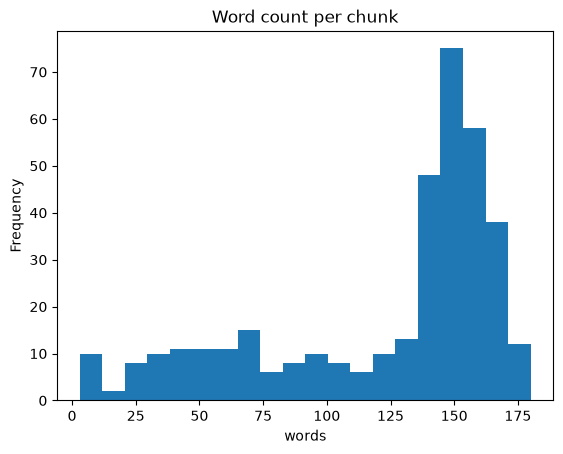

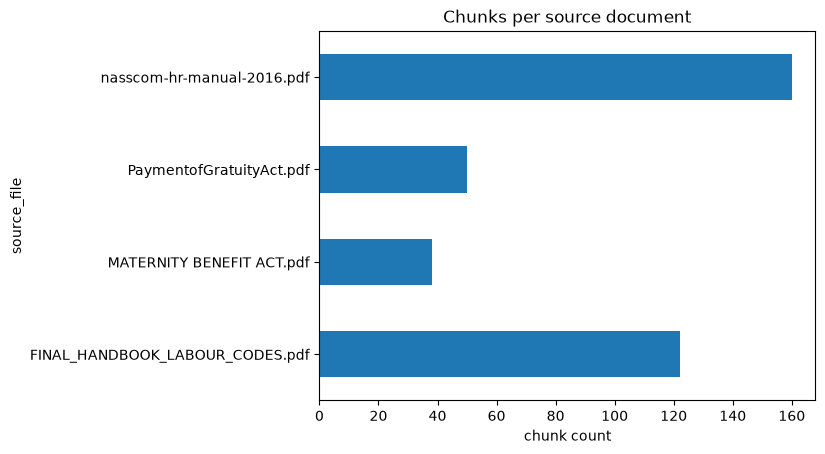

In [7]:
if not df_chunks.empty:
    df_chunks["word_count"].plot(
        kind="hist", bins=20, title="Word count per chunk", xlabel="words"
    )
    plt.show()

    df_chunks.groupby("source_file").size().plot(
        kind="barh", title="Chunks per source document", xlabel="chunk count"
    )
    plt.show()
else:
    print("No chunks to plot yet — add PDFs first.")


### 📌 Observation — what the two plots actually show

**Plot 1 — Word count per chunk**

- Sharply **right-loaded**: the 140–155 word bin holds ~75 chunks, 155–165 holds ~58, and 130–140 holds ~48. Together with the neighbouring bins, roughly **230 of 370 chunks (~62%) sit above 125 words**, i.e. pressed against the 1000-char cap.
- A **long flat left tail** runs from ~5 to ~125 words at only ~8–15 chunks per bin — these are page remainders (the last chunk of each page) plus whole short structural pages.
- The shape tells us the recursive splitter is **filling its budget and then cutting**, rather than finding a natural paragraph boundary near the limit. Legal/handbook text has long unbroken paragraphs, so `\n\n` separators are not conveniently placed.

**Plot 2 — Chunks per source document**

- `nasscom-hr-manual-2016.pdf` ≈ **160**, `FINAL_HANDBOOK_LABOUR_CODES.pdf` ≈ **122**, `PaymentofGratuityAct.pdf` ≈ **50**, `MATERNITY BENEFIT ACT.pdf` ≈ **38**.
- The two Nasscom documents hold **~76% of all vectors**; the Maternity Benefit Act holds **~10%**.

### 💡 Pipeline / Engineering decision

- Because chunks are routinely cut at the cap rather than at a paragraph break, **`CHUNK_OVERLAP` is not optional** — set it to ~150–200 chars (~15–20% of `CHUNK_SIZE`) so a clause severed mid-sentence still appears whole in the neighbouring chunk. Without overlap, this distribution would guarantee truncated answers.
- Keep the recursive separator ladder `["\n\n", "\n", " ", ""]` so the splitter still prefers paragraph → line → word boundaries and only hard-cuts as a last resort.
- The **76 / 10 imbalance is the main retrieval risk in this project.** A plain top-k similarity search can return all `k` hits from the Nasscom manual simply because it dominates the vector space. Mitigations carried into the pipeline: retrieve with **MMR (diversity-aware) rather than pure similarity**, keep `k` at 4–5 rather than 2, and **always display `source_file` per retrieved chunk** so the user can see the answer leans on one document.
- Build the evaluation question set with **deliberate coverage of all four documents** — including maternity-leave and gratuity-calculation questions — instead of sampling questions randomly, which would over-test the two large documents and hide weak recall on the small ones.


## 4. Eyeball a few sample chunks

Quick sanity check before wiring up retrieval: do these chunks actually read as coherent policy text, or did PDF extraction mangle formatting (tables, multi-column layouts, etc. are common culprits)?


In [8]:
for doc in documents[:3]:
    print(f"--- {doc.metadata['source_file']}, p.{doc.metadata['page_number']} "
          f"(chunk {doc.metadata['chunk_index']}) ---")
    print(doc.page_content[:400])
    print()


--- FINAL_HANDBOOK_LABOUR_CODES.pdf, p.1 (chunk 0) ---
1
Handbook on Labour Codes
HANDBOOK ON
LABOUR CODES
A ready reference for CXOs and public 
policy professionals highlighting key 
changes in the legal framework for the 
IT and BPM industry
April 2024
Knowledge Partner
Nishith Desai Associates

--- FINAL_HANDBOOK_LABOUR_CODES.pdf, p.2 (chunk 0) ---
2
Handbook on Labour Codes
Nasscom represents the voice of over $250 billion technology industry in India with the vision to 
establish the nation as the world’s leading technology ecosystem. Boasting a diverse and influential 
community of over 3000 member companies, our network spans the entire spectrum of the industry 
from DeepTech and AI start-ups to multinationals and from products to servic

--- FINAL_HANDBOOK_LABOUR_CODES.pdf, p.2 (chunk 1) ---
in everything we do, we will continue to champion the need for diversity and equal opportunity.
Write to us at policy@nasscom.in or visit us at X for updates @NasscomPolicy.
At Nishith Des

### 📌 Observation — what the sample chunks actually show

- **Extraction quality is good.** The text reads as coherent English sentences — no interleaved columns, no character-level gibberish, no table cells collapsed into nonsense. This rules out the most common PDF-to-RAG failure mode before any LLM is wired up.
- **But the first three chunks contain zero answerable policy content.** Chunk 0 of page 1 is the **cover page** (title, subtitle, "April 2024", "Knowledge Partner — Nishith Desai Associates"). Page 2 chunks 0 and 1 are **Nasscom organisational boilerplate** ("represents the voice of over $250 billion technology industry...") and **law-firm marketing copy** ("Asia's most Innovative Law Firm").
- Line breaks from the PDF layout survive inside chunks (`1\nHandbook on Labour Codes\nHANDBOOK ON\nLABOUR CODES`), so the cover chunk is mostly repeated title fragments.
- A **contact email (`policy@nasscom.in`) is present in the embedded text**, i.e. the vector store contains contact details lifted from source documents.
- Front-matter is systematic, not accidental: every PDF starts with 1–3 pages of it, so roughly **6–12 of the 370 chunks are non-answerable front-matter** (~2–3%).

### 💡 Pipeline / Engineering decision

- Do **not** strip front matter by page index (e.g. "skip first 2 pages"). It is brittle — the Acts and the handbooks have different front-matter lengths, and a new PDF would break the rule silently. The **min-length filter plus semantic retrieval** already suppress most of it.
- At ~2–3% of the index, front-matter noise is accepted as a known trade-off. It is handled at the **prompt layer instead**: the system prompt instructs the model to answer strictly from retrieved context and to reply *"this is not covered in the available policy documents"* when the context is irrelevant — so the worst case is an honest refusal, not marketing copy presented as HR policy.
- Because the extracted text is clean, **no text-normalisation/cleaning stage is added** to the pipeline. Fewer transformations means retrieved context matches the source PDF verbatim, which keeps citations trustworthy.
- The embedded email address is noted as a minor data-hygiene point: the corpus is public-domain legislation and published industry handbooks, so no redaction stage is required — but this check belongs in the ingest checklist before any internal, employee-specific document is ever added to `data/policies/`.


## 5. Tuning signal for `config.py` / `.env`

If most chunks are far smaller than `CHUNK_SIZE` (1000 chars by default), your PDFs likely have short paragraphs/lots of line breaks — consider lowering `CHUNK_SIZE` so retrieval doesn't waste context window on padding. If chunks are consistently hitting the max size, unrelated content may be getting concatenated — consider adding more separators or lowering `CHUNK_SIZE` for tighter topic boundaries.


In [9]:
if not df_chunks.empty:
    print(f"Configured CHUNK_SIZE: {settings.CHUNK_SIZE} chars")
    print(f"Actual mean chunk length: {df_chunks['char_count'].mean():.0f} chars")
    print(f"Actual max chunk length:  {df_chunks['char_count'].max()} chars")


Configured CHUNK_SIZE: 1000 chars
Actual mean chunk length: 782 chars
Actual max chunk length:  999 chars


### 📌 Observation — what the output actually shows

- Configured `CHUNK_SIZE` = **1000 chars**; actual **mean = 782 chars (78% utilisation)**; actual **max = 999 chars**.
- Max of 999 against a cap of 1000 is the clean confirmation that the splitter's hard limit is enforced — nothing overflows into an oversized vector.
- Mean at 78% is the healthy middle case described in the tuning note above: chunks are **not** collapsing far below the cap (which would mean short fragmented paragraphs and wasted retrieval slots), and they are **not** all pinned at exactly 1000 (which would mean unrelated sections are being welded together indiscriminately).
- Read together with the median of 955 from the `describe()` output, the 782 mean is explained entirely by the short page-remainder tail — not by systematic under-filling.

### 💡 Pipeline / Engineering decision

- **Keep `CHUNK_SIZE = 1000` in `config.py`.** The data supports it from both directions: lowering it would fragment legal clauses that clearly run longer than 500 chars, and raising it would start merging unrelated sections of the HR manual into one vector and blur retrieval.
- Keep `CHUNK_SIZE` / `CHUNK_OVERLAP` as **`.env`-driven settings in `config.py`, never hardcoded in `rag_pipeline.py`** — so re-tuning against a new corpus is a config change, not a code change, and this notebook can be re-run to re-validate.
- Persist `4 PDFs → 148 pages → 370 chunks → mean 782 / max 999 chars` in the README as the **corpus fingerprint**. Any future ingest that drifts materially from these numbers means the corpus, the extractor, or the splitter config changed — and this notebook is the diagnostic to re-run first.


---

## 6. Summary — decisions this EDA locked into the pipeline

| # | Evidence from this notebook | Decision carried into code |
|---|---|---|
| 1 | 4 PDFs discovered, all with real text layers (52 / 10 / 64 / 22 pages) | No OCR dependency; glob-based discovery; loud failure guard if a PDF yields 0 pages |
| 2 | Bimodal page length — ~35 structural pages under 150 words, content mode at ~470 words | Page-level embedding rejected; chunking mandatory; min-length filter on pages |
| 3 | 370 chunks total, min chunk = 17 chars | Flat vector index, full rebuild per ingest; min-chunk filter (~50 chars) |
| 4 | ~62% of chunks pressed against the 1000-char cap | `CHUNK_OVERLAP` ~150–200 chars is mandatory; recursive separator ladder retained |
| 5 | Corpus imbalance — 2 Nasscom docs hold ~76% of vectors | MMR retrieval over plain similarity, `k`=4–5, per-chunk `source_file` citation, coverage-balanced eval set |
| 6 | Clean extraction but ~2–3% front-matter chunks | No text-cleaning stage; grounded prompt with explicit "not covered in the policy documents" refusal |
| 7 | Mean 782 / max 999 vs configured 1000 | `CHUNK_SIZE = 1000` retained; chunk params stay `.env`-driven via `config.py` |

**Corpus fingerprint:** `4 PDFs → 148 pages → 370 chunks → mean 782 chars, max 999 chars`. Re-run this notebook after any corpus change and compare against these numbers.
